In [80]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


① 예금은행 대출금리 파일 업로드


Saving 예금은행_대출금리_신규취급액_기준__20260619220328.xlsx to 예금은행_대출금리_신규취급액_기준__20260619220328 (3).xlsx
② 아파트 거래량 파일 업로드


Saving 아파트매매거래+현황_20260619221341.xlsx to 아파트매매거래+현황_20260619221341 (3).xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


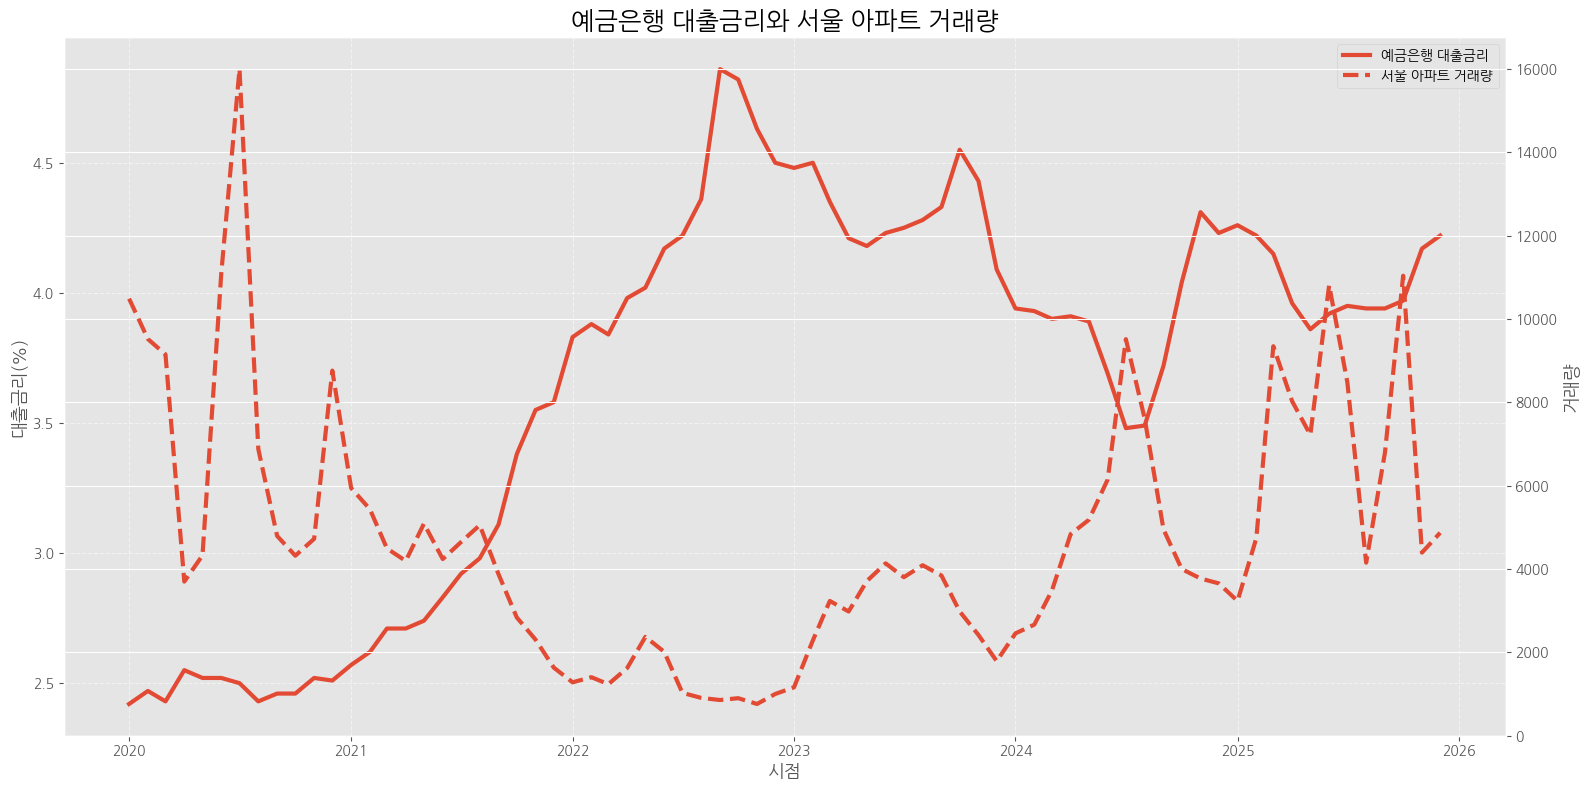



1~12개월 시차 상관분석 결과


,시차(개월),상관계수,절대값
0,1,-0.4396,0.4396
1,2,-0.3658,0.3658
2,3,-0.2830,0.2830
3,4,-0.2464,0.2464
4,12,0.2112,0.2112
5,5,-0.2077,0.2077
6,11,0.1422,0.1422
7,6,-0.1270,0.1270
8,10,0.1129,0.1129
9,9,0.0934,0.0934




최종 결론
1~12개월 범위에서 절대 상관계수가 가장 높은 시차는 1개월입니다.
상관계수 : -0.4396

결론 : 대출금리 변화는 약 1개월 후 서울 아파트 거래량 감소와 가장 강한 관계를 보입니다.


In [27]:
# ============================================================
# 예금은행 대출금리 vs 서울 아파트 거래량
# 시차분석 (1~12개월)
# ============================================================

!apt-get -qq install fonts-nanum

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from google.colab import files
from IPython.display import display

# ============================================================
# 한글 설정
# ============================================================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 파일 업로드
# ============================================================

print("① 예금은행 대출금리 파일 업로드")
uploaded1 = files.upload()
rate_file = list(uploaded1.keys())[0]

print("② 아파트 거래량 파일 업로드")
uploaded2 = files.upload()
trade_file = list(uploaded2.keys())[0]

# ============================================================
# 데이터 읽기
# ============================================================

rate_raw = pd.read_excel(rate_file)
trade_raw = pd.read_excel(trade_file)

# ============================================================
# 금리 데이터 변환
# ============================================================

rate_series = rate_raw.iloc[0,1:]

rate_df = pd.DataFrame({
    'date': rate_series.index.astype(str),
    'rate': rate_series.values
})

rate_df['date'] = pd.to_datetime(
    rate_df['date'],
    format='%Y.%m'
)

# ============================================================
# 거래량 데이터 변환
# ============================================================

trade_series = trade_raw.iloc[1,1:]

trade_df = pd.DataFrame({
    'date': trade_series.index.astype(str),
    'trade': trade_series.values
})

trade_df['date'] = (
    trade_df['date']
    .str.replace(' ','')
)

trade_df['date'] = pd.to_datetime(
    trade_df['date'],
    format='%Y.%m'
)

# ============================================================
# 숫자형 변환
# ============================================================

rate_df['rate'] = pd.to_numeric(
    rate_df['rate'],
    errors='coerce'
)

trade_df['trade'] = pd.to_numeric(
    trade_df['trade'],
    errors='coerce'
)

# ============================================================
# 병합
# ============================================================

df = pd.merge(
    rate_df,
    trade_df,
    on='date',
    how='inner'
)

df = df.sort_values('date')

# ============================================================
# 그래프
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(16,8)
)

ax2 = ax1.twinx()

ax1.plot(
    df['date'],
    df['rate'],
    linewidth=3,
    label='예금은행 대출금리'
)

ax2.plot(
    df['date'],
    df['trade'],
    linewidth=3,
    linestyle='--',
    label='서울 아파트 거래량'
)

ax1.set_xlabel(
    '시점',
    fontsize=13,
    fontweight='bold'
)

ax1.set_ylabel(
    '대출금리(%)',
    fontsize=13,
    fontweight='bold'
)

ax2.set_ylabel(
    '거래량',
    fontsize=13,
    fontweight='bold'
)

plt.title(
    '예금은행 대출금리와 서울 아파트 거래량',
    fontsize=18,
    fontweight='bold'
)

ax1.grid(
    True,
    linestyle='--',
    alpha=0.5
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.tight_layout()
plt.show()

# ============================================================
# 1~12개월 시차분석
# ============================================================

lag_result = []

for lag in range(1, 13):

    corr = df['rate'].corr(
        df['trade'].shift(-lag)
    )

    lag_result.append([
        lag,
        round(corr,4),
        round(abs(corr),4)
    ])

lag_df = pd.DataFrame(
    lag_result,
    columns=[
        '시차(개월)',
        '상관계수',
        '절대값'
    ]
)

lag_df = lag_df.sort_values(
    '절대값',
    ascending=False
).reset_index(drop=True)

# ============================================================
# 시차 분석 결과
# ============================================================

print("\n")
print("="*80)
print("1~12개월 시차 상관분석 결과")
print("="*80)

display(lag_df)

# ============================================================
# 최적 시차
# ============================================================

best = lag_df.iloc[0]

best_lag = int(best['시차(개월)'])
best_corr = float(best['상관계수'])

print("\n")
print("="*80)
print("최종 결론")
print("="*80)

print(
    f"1~12개월 범위에서 절대 상관계수가 가장 높은 시차는 "
    f"{best_lag}개월입니다."
)

print(
    f"상관계수 : {best_corr:.4f}"
)

if best_corr < 0:

    print(
        f"\n결론 : 대출금리 변화는 약 {best_lag}개월 후 "
        f"서울 아파트 거래량 감소와 가장 강한 관계를 보입니다."
    )

else:

    print(
        f"\n결론 : 대출금리 변화는 약 {best_lag}개월 후 "
        f"서울 아파트 거래량 증가와 가장 강한 관계를 보입니다."
    )